# Ablation Study: SimpleBaseline Backbone 교체

## 실험 목적
- Backbone을 ResNet50 / ResNet101 / ResNet152로 교체하여 성능 비교
- 동일 조건(epochs=5, batch_size=16, seed=42) 하에서 backbone 깊이에 따른 영향 분석

## 팀 공통 설정
| 항목 | 값 |
|---|---|
| Epochs | 5 |
| Batch Size | 16 |
| Seed | 42 |
| Learning Rate | 0.0007 |
| Dataset | MPII Human Pose |

## 담당 파트
- SimpleBaseline(ResNet50)
- SimpleBaseline + ResNet101
- SimpleBaseline + ResNet152

---
## 0. 라이브러리 설치 및 환경 설정

In [1]:
!pip install ray tfrecord gdown -q

In [2]:
# ============================================================
# 라이브러리 import
# ray는 반드시 torch 이후에 import (순서 바뀌면 오류 발생)
# ============================================================
import io, json, os, math, pickle, random

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision.models as models
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader

import ray
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# ============================================================
# 팀 공통 하이퍼파라미터 (팀원 간 통일)
# ============================================================
SEED       = 42    # 재현성 보장을 위한 시드
EPOCHS     = 5     # 학습 epoch 수
BATCH_SIZE = 16    # 배치 크기
LR         = 0.0007  # Adam optimizer 초기 학습률
NUM_HEATMAP = 16   # MPII keypoint 수

# ============================================================
# 시드 고정 (CPU, GPU, numpy, python random 전부 고정)
# → 동일 조건에서 실험 재현 가능하게 만듦
# ============================================================
def set_seed(seed):
    random.seed(seed)                        # Python 기본 random
    np.random.seed(seed)                     # NumPy random
    torch.manual_seed(seed)                  # CPU 연산
    torch.cuda.manual_seed(seed)             # 단일 GPU
    torch.cuda.manual_seed_all(seed)         # 멀티 GPU
    # 완전한 재현성: 속도 저하 감수하고 결정론적 연산 강제
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False   # benchmark=True면 최적 알고리즘 탐색 → 비결정적

set_seed(SEED)

# ============================================================
# 프로젝트 경로 설정
# ============================================================
PROJECT_PATH   = os.path.join(os.getenv('HOME'), 'work/노드실습/GoingDeeper/4.Poseestimation/mpii')
IMAGE_PATH     = os.path.join(PROJECT_PATH, 'images')
MODEL_PATH     = os.path.join(PROJECT_PATH, 'models')
PT_RECORD_PATH = os.path.join(PROJECT_PATH, 'ptrecords_mpii')
TRAIN_JSON     = os.path.join(PROJECT_PATH, 'mpii_human_pose_v1_u12_2', 'train.json')
VALID_JSON     = os.path.join(PROJECT_PATH, 'mpii_human_pose_v1_u12_2', 'validation.json')

IMAGE_SHAPE  = (256, 256, 3)  # 모델 입력 크기 (H, W, C)
HEATMAP_SIZE = (64, 64)       # 출력 heatmap 크기 (입력의 1/4)

os.makedirs(MODEL_PATH, exist_ok=True)

# GPU 설정
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(f'Device: {device}')
print(f'PyTorch: {torch.__version__}')
print(f'CUDA 사용 가능: {torch.cuda.is_available()}')
print(f'Seed: {SEED}, Epochs: {EPOCHS}, Batch: {BATCH_SIZE}, LR: {LR}')
print(f'train.json 존재: {os.path.exists(TRAIN_JSON)}')
print(f'images 존재: {os.path.exists(IMAGE_PATH)}')
print('완료')

Device: cuda
PyTorch: 2.7.1+cu118
CUDA 사용 가능: True
Seed: 42, Epochs: 5, Batch: 16, LR: 0.0007
train.json 존재: True
images 존재: True
완료


---
## 1. 데이터 전처리 파이프라인

In [3]:
# ============================================================
# MPII 어노테이션 파싱
# JSON의 raw 어노테이션 → 사용하기 편한 딕셔너리로 변환
# 핵심: filepath를 추가하여 이미지 직접 로드 가능하게 만듦
# ============================================================
def parse_one_annotation(anno, image_dir):
    return {
        'filename'        : anno['image'],
        'filepath'        : os.path.join(image_dir, anno['image']),  # 전체 경로 추가
        'joints_visibility': anno['joints_vis'],  # 가시성: 0=미검출, 1=검출
        'joints'          : anno['joints'],       # 16개 keypoint [[x,y], ...]
        'center'          : anno['center'],       # 사람 중심 좌표 [x, y]
        'scale'           : anno['scale'],        # body_height = scale * 200 (픽셀)
    }


# ============================================================
# 2D Gaussian Heatmap 생성
# → Pose Estimation은 좌표 대신 heatmap을 학습 타겟으로 사용
# → keypoint 위치에 Gaussian 분포(종 모양)를 그려 학습 안정성 향상
# ============================================================
def generate_2d_gaussian(height, width, y0, x0, visibility=2, sigma=1, scale=12):
    """
    단일 keypoint에 대한 Gaussian heatmap 생성

    Args:
        height, width : heatmap 크기 (= 64x64)
        y0, x0        : keypoint 중심 좌표 (heatmap 픽셀 기준)
        visibility    : 0이면 빈 heatmap 반환 (미검출 keypoint 제외)
        sigma         : Gaussian 퍼짐 정도 (클수록 넓게 분포)
        scale         : Gaussian 최댓값 (= 12)
    """
    heatmap = torch.zeros((height, width), dtype=torch.float32)

    # Gaussian patch 범위: 중심 ± 3σ
    xmin, ymin = x0 - 3*sigma, y0 - 3*sigma
    xmax, ymax = x0 + 3*sigma, y0 + 3*sigma

    # heatmap 범위 밖이거나 미검출이면 빈 heatmap 반환
    if xmin >= width or ymin >= height or xmax < 0 or ymax < 0 or visibility == 0:
        return heatmap

    # patch 크기: 6σ+1 (홀수로 중심 명확히)
    size = int(6*sigma + 1)  # sigma=1 → size=7
    g    = torch.arange(0, size, dtype=torch.float32)
    x_g, y_g = torch.meshgrid(g, g, indexing='xy')
    cx, cy   = size//2, size//2

    # 2D Gaussian 수식: exp(-(dx²+dy²) / 2σ²) × scale
    patch = torch.exp(-(((x_g-cx)**2 + (y_g-cy)**2) / (2*sigma**2))) * scale

    # heatmap 경계 밖으로 나가는 patch 부분 클리핑
    # → patch 좌표계와 heatmap 좌표계를 맞춰 겹치는 영역만 복사
    px_min = max(0, -xmin);          py_min = max(0, -ymin)
    px_max = min(xmax, width) - xmin; py_max = min(ymax, height) - ymin
    hx_min = max(0, xmin);           hy_min = max(0, ymin)
    hx_max = min(xmax, width);       hy_max = min(ymax, height)

    heatmap[hy_min:hy_max, hx_min:hx_max] = \
        patch[int(py_min):int(py_max), int(px_min):int(px_max)]
    return heatmap


# ============================================================
# Preprocessor: 이미지 + 어노테이션 → 학습 가능한 텐서 변환
# MPIIDataset의 transform으로 사용됨
# ============================================================
class Preprocessor(object):
    def __init__(self, image_shape=(256,256,3), heatmap_shape=(64,64,16), is_train=False):
        self.is_train      = is_train
        self.image_shape   = image_shape   # (H, W, C)
        self.heatmap_shape = heatmap_shape # (H, W, num_keypoint)

    def __call__(self, example):
        features = self._parse(example)
        image    = Image.open(io.BytesIO(features['image/encoded']))

        # 학습 시: random margin(0.1~0.3)으로 augmentation
        # 검증 시: 고정 margin=0.2로 재현성 보장
        margin = torch.empty(1).uniform_(0.1, 0.3).item() if self.is_train else 0.2
        image, kp_x, kp_y = self._crop_roi(image, features, margin)

        # resize → (256, 256)
        image = image.resize((self.image_shape[1], self.image_shape[0]))

        # 정규화: uint8(0~255) → float32(-1~1)
        # /127.5 - 1.0: 중심을 0으로 만들어 학습 안정성 향상
        img_np = np.array(image).astype(np.float32) / 127.5 - 1.0

        # (H,W,C) → (C,H,W): PyTorch Conv 입력 형식
        img_tensor = torch.from_numpy(img_np).permute(2, 0, 1)

        # 16채널 heatmap 생성
        heatmaps = self._make_heatmaps(features, kp_x, kp_y)
        return img_tensor, heatmaps

    def _parse(self, example):
        """MPIIDataset example → feature 딕셔너리"""
        anno = example['annotation']
        joints = anno['joints']
        features = {
            'image/encoded'          : self._img_to_bytes(example['image']),
            'image/object/parts/x'   : [j[0] for j in joints],
            'image/object/parts/y'   : [j[1] for j in joints],
            'image/object/parts/v'   : anno.get('joints_vis', [1]*len(joints)),
            'image/object/center/x'  : anno['center'][0],
            'image/object/center/y'  : anno['center'][1],
            'image/object/scale'     : anno['scale'],
        }
        return features

    def _img_to_bytes(self, image):
        """PIL Image → JPEG bytes (메모리 내 처리)"""
        buf = io.BytesIO()
        image.save(buf, format='JPEG')
        return buf.getvalue()

    def _crop_roi(self, image, features, margin=0.2):
        """
        유효한 keypoint(좌표>0)의 bbox + margin으로 사람 영역 crop
        → crop 후 keypoint 좌표를 0~1로 정규화
        """
        W, H = image.size  # PIL: (width, height)
        kp_x = torch.tensor(features['image/object/parts/x'], dtype=torch.int32)
        kp_y = torch.tensor(features['image/object/parts/y'], dtype=torch.int32)

        # body_height = scale * 200 (MPII 단위 정의)
        body_h = features['image/object/scale'] * 200.0

        # 유효한 keypoint만 선택 (0 이하 = 화면 밖 or 미검출)
        valid_x = kp_x[kp_x > 0]
        valid_y = kp_y[kp_y > 0]

        # bounding box 계산 후 margin 추가
        extra = int(body_h * margin)
        xmin = max(int(valid_x.min()) - extra, 0)
        xmax = min(int(valid_x.max()) + extra, W)
        ymin = max(int(valid_y.min()) - extra, 0)
        ymax = min(int(valid_y.max()) + extra, H)

        cropped = image.crop((xmin, ymin, xmax, ymax))
        nw, nh  = xmax - xmin, ymax - ymin

        # keypoint 좌표를 crop 기준으로 정규화 (0~1)
        norm_x = (kp_x.float() - xmin) / nw
        norm_y = (kp_y.float() - ymin) / nh
        return cropped, norm_x, norm_y

    def _make_heatmaps(self, features, kp_x, kp_y):
        """
        16개 keypoint 각각에 Gaussian heatmap 생성 후 스택
        → (num_keypoint, H, W) 형태로 반환 (PyTorch Conv 형식)
        """
        H, W, C = self.heatmap_shape
        v = torch.tensor(features['image/object/parts/v'], dtype=torch.float32)

        # 정규화 좌표(0~1) → heatmap 픽셀 좌표
        x = torch.round(kp_x * W).to(torch.int32)
        y = torch.round(kp_y * H).to(torch.int32)

        maps = []
        for i in range(C):  # C = 16 (keypoint 수)
            maps.append(generate_2d_gaussian(
                H, W,
                int(y[i].item()), int(x[i].item()),
                visibility=int(v[i].item())
            ))
        return torch.stack(maps, dim=0)  # (16, H, W)


# ============================================================
# MPIIDataset: PyTorch Dataset 상속
# → DataLoader와 함께 배치 학습에 사용
# ============================================================
class MPIIDataset(Dataset):
    def __init__(self, annotation_file, image_dir, transform=None):
        self.transform = transform
        with open(annotation_file, 'r') as f:
            annos = json.load(f)
        # 초기화 시 전체 어노테이션 파싱 (1회)
        self.annotations = [parse_one_annotation(a, image_dir) for a in annos]

    def __len__(self):
        return len(self.annotations)

    def __getitem__(self, idx):
        anno  = self.annotations[idx]
        image = Image.open(anno['filepath']).convert('RGB')
        if self.transform:
            # Preprocessor 적용 → (image_tensor, heatmaps) 반환
            return self.transform({'image': image, 'annotation': anno})
        return image, anno


def create_dataloader(annotation_file, image_dir, batch_size, is_train=True):
    """
    DataLoader 생성
    - pin_memory=True : CPU 고정 메모리 사용 → GPU 전송 속도 향상
    - prefetch_factor=2: 워커당 2배치 미리 로드
    - num_workers=4   : 병렬 데이터 로딩
    """
    preprocess = Preprocessor(
        image_shape=IMAGE_SHAPE,
        heatmap_shape=(HEATMAP_SIZE[0], HEATMAP_SIZE[1], NUM_HEATMAP),
        is_train=is_train
    )
    dataset = MPIIDataset(annotation_file, image_dir, transform=preprocess)
    return DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=is_train,       # 학습 시만 섞기
        num_workers=2,          # 최초 4에서 shared memory 부족으로 2로 수정
        pin_memory=True,
        drop_last=False,
        prefetch_factor=2,
        worker_init_fn=lambda wid: set_seed(SEED + wid)  # 각 worker도 seed 고정
    )

print('완료')

완료


---
## 2. SimpleBaseline 모델 (Backbone 교체 가능)

In [4]:
# ============================================================
# DeconvLayer: Simple Baseline의 핵심 업샘플링 블록
# ConvTranspose2d(stride=2) → BN → ReLU → 해상도 2배
# kernel=4, stride=2, padding=1 조합으로 정확히 2배 업샘플링
# ============================================================
class DeconvLayer(nn.Module):
    def __init__(self, in_channels, num_layers=3, num_filters=256, kernel_size=4):
        """
        Args:
            in_channels : backbone 출력 채널 수 (ResNet50=2048, 101/152=2048)
            num_layers  : deconv 반복 횟수 (기본 3 → 8→16→32→64)
            num_filters : 각 deconv 레이어의 출력 채널 수 (기본 256)
            kernel_size : ConvTranspose2d의 kernel 크기 (기본 4)
        """
        super(DeconvLayer, self).__init__()
        layers = []
        current_ch = in_channels  # 첫 레이어 입력 채널 = backbone 출력 채널

        for _ in range(num_layers):
            # ConvTranspose2d: stride=2로 해상도 2배 업샘플링
            # kernel=4, padding=1 → 출력 크기 = 입력×2 (정확히 2배)
            layers.append(nn.ConvTranspose2d(
                current_ch, num_filters,
                kernel_size=kernel_size, stride=2, padding=1,
                output_padding=0, bias=False
            ))
            layers.append(nn.BatchNorm2d(num_filters))  # 학습 안정성
            layers.append(nn.ReLU(inplace=True))
            current_ch = num_filters  # 2번째 레이어부터는 num_filters→num_filters

        self.deconv_layers = nn.Sequential(*layers)

    def forward(self, x):
        return self.deconv_layers(x)


# ============================================================
# SimpleBaseline: Backbone 교체 가능한 버전
# 논문: "Simple Baselines for Human Pose Estimation" (2018)
#
# 전체 흐름:
# 입력(B,3,256,256)
#   → ResNet Backbone → (B, backbone_out_ch, 8, 8)
#   → DeconvLayer×3  → (B, 256, 64, 64)
#   → Conv1×1        → (B, num_heatmap, 64, 64)
# ============================================================
class SimpleBaseline(nn.Module):
    # backbone 이름 → (모델 생성 함수, 출력 채널 수) 매핑
    # ResNet 계열은 모두 마지막 레이어 출력이 2048채널
    BACKBONE_MAP = {
        'resnet50' : (models.resnet50,  2048),
        'resnet101': (models.resnet101, 2048),
        'resnet152': (models.resnet152, 2048),
    }

    def __init__(self, backbone='resnet50', num_heatmap=16, pretrained=True):
        """
        Args:
            backbone    : 사용할 backbone 이름 ('resnet50', 'resnet101', 'resnet152')
            num_heatmap : 출력 keypoint 수 (MPII=16)
            pretrained  : ImageNet pretrained 가중치 사용 여부
        """
        super(SimpleBaseline, self).__init__()
        self.backbone_name = backbone

        # backbone 이름 유효성 검사
        if backbone not in self.BACKBONE_MAP:
            raise ValueError(f'지원하지 않는 backbone: {backbone}. '
                             f'선택 가능: {list(self.BACKBONE_MAP.keys())}')

        model_fn, out_ch = self.BACKBONE_MAP[backbone]

        # backbone 로드
        # [:-2]: 마지막 2개 레이어(AvgPool, FC) 제거 → feature map 유지
        # 제거 이유: FC는 분류용이므로 pose estimation에 불필요
        if pretrained:
            # torchvision 0.13+ 권장 방식
            weights_map = {
                'resnet50' : models.ResNet50_Weights.IMAGENET1K_V1,
                'resnet101': models.ResNet101_Weights.IMAGENET1K_V1,
                'resnet152': models.ResNet152_Weights.IMAGENET1K_V1,
            }
            resnet = model_fn(weights=weights_map[backbone])
        else:
            resnet = model_fn(weights=None)

        self.backbone = nn.Sequential(*list(resnet.children())[:-2])

        # DeconvLayer: backbone 출력(8×8) → heatmap 크기(64×64)
        # in_channels=out_ch (backbone 출력 채널을 첫 입력으로)
        self.deconv_layers = DeconvLayer(in_channels=out_ch, num_layers=3, num_filters=256)

        # final_layer: 256채널 → num_heatmap채널 (각 채널 = 각 keypoint heatmap)
        # 1×1 Conv: 공간 해상도 유지하며 채널만 변환
        self.final_layer = nn.Conv2d(256, num_heatmap, kernel_size=1, padding=0)

        # 가중치 초기화 (deconv, final layer)
        self._init_weights()

    def _init_weights(self):
        """
        backbone 제외 레이어 가중치 초기화
        - ConvTranspose2d: Kaiming Normal (ReLU에 최적화)
        - BatchNorm: weight=1, bias=0
        - Conv2d (final): Normal(0, 0.01)
        """
        for m in self.deconv_layers.modules():
            if isinstance(m, nn.ConvTranspose2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)
        nn.init.normal_(self.final_layer.weight, std=0.01)
        nn.init.constant_(self.final_layer.bias, 0)

    def forward(self, x):
        # (B, 3, 256, 256) → (B, 2048, 8, 8): backbone 특징 추출
        x = self.backbone(x)
        # (B, 2048, 8, 8) → (B, 256, 64, 64): deconv 3회 (해상도 8배 복원)
        x = self.deconv_layers(x)
        # (B, 256, 64, 64) → (B, num_heatmap, 64, 64): keypoint별 heatmap
        x = self.final_layer(x)
        # Trainer의 compute_loss와 호환되도록 리스트로 감싸 반환
        return [x]

    def count_params(self):
        """학습 가능한 파라미터 수 반환"""
        return sum(p.numel() for p in self.parameters() if p.requires_grad)


# ============================================================
# 빠른 모델 구조 확인 (shape 검증)
# ============================================================
print('=== 모델 구조 확인 ===')
dummy = torch.zeros(1, 3, 256, 256)  # 더미 입력
for name in ['resnet50', 'resnet101', 'resnet152']:
    m = SimpleBaseline(backbone=name, pretrained=False)  # pretrained=False로 빠르게 확인
    with torch.no_grad():
        out = m(dummy)
    print(f'{name:12s} | 출력 shape: {out[0].shape} | 파라미터: {m.count_params():,}')

print('완료')

=== 모델 구조 확인 ===
resnet50     | 출력 shape: torch.Size([1, 16, 64, 64]) | 파라미터: 33,999,440
resnet101    | 출력 shape: torch.Size([1, 16, 64, 64]) | 파라미터: 52,991,568
resnet152    | 출력 shape: torch.Size([1, 16, 64, 64]) | 파라미터: 68,635,216
완료


---
## 3. 학습 엔진 (Trainer)

In [5]:
# ============================================================
# Trainer: 학습/검증 루프 관리
#
# Loss: 가중치 적용 MSE
#   → keypoint 위치(labels>0): 가중치 82
#   → 배경(labels=0)         : 가중치  1
#   → 이유: heatmap 대부분이 배경 → 불균형 보정
# ============================================================
class Trainer:
    def __init__(self, model, epochs, batch_size, lr, device):
        """
        Args:
            model      : 학습할 PyTorch 모델
            epochs     : 전체 학습 epoch 수
            batch_size : 배치 크기 (loss 정규화에 사용)
            lr         : 초기 학습률
            device     : 'cuda' or 'cpu'
        """
        self.model      = model
        self.epochs     = epochs
        self.batch_size = batch_size
        self.device     = device

        # Adam optimizer: momentum + adaptive lr → 빠른 수렴
        self.optimizer  = optim.Adam(model.parameters(), lr=lr)
        self.current_lr = lr

        # 학습률 decay 관련
        self.last_val_loss   = math.inf
        self.lowest_val_loss = math.inf
        self.patience_count  = 0
        self.max_patience    = 10  # val_loss 개선 없이 10 epoch → lr /10

        # loss 기록 (시각화용)
        self.train_losses = []
        self.val_losses   = []
        self.best_model   = None

        # 멀티 GPU 지원
        if torch.cuda.device_count() > 1:
            print(f'멀티 GPU: {torch.cuda.device_count()}개')
            self.model = nn.DataParallel(self.model)
        self.model.to(device)

    def _lr_decay(self):
        """patience 기반 학습률 감소 (개선 없으면 lr / 10)"""
        if self.patience_count >= self.max_patience:
            self.current_lr /= 10.0
            self.patience_count = 0
            print(f'  LR decay: {self.current_lr:.2e}')
        elif self.last_val_loss == self.lowest_val_loss:
            self.patience_count = 0
        self.patience_count += 1
        for pg in self.optimizer.param_groups:
            pg['lr'] = self.current_lr

    def _compute_loss(self, labels, outputs):
        """
        가중치 적용 MSE loss
        → keypoint 있는 위치(labels>0)에 더 큰 패널티 부여
        → heatmap 대부분이 0(배경)이므로 불균형 보정 필요
        """
        loss = 0
        for output in outputs:  # SimpleBaseline: [x] 1개 / Hourglass: 4개
            # keypoint 위치: 81+1=82, 배경: 1
            weights = (labels > 0).float() * 81 + 1
            loss += ((labels - output)**2 * weights).mean() / self.batch_size
        return loss

    def _train_step(self, images, labels):
        """단일 배치 학습 (forward → loss → backward → step)"""
        self.model.train()  # BN, Dropout 학습 모드
        images, labels = images.to(self.device), labels.to(self.device)
        self.optimizer.zero_grad()        # gradient 초기화
        outputs = self.model(images)      # forward
        loss    = self._compute_loss(labels, outputs)
        loss.backward()                   # backprop
        self.optimizer.step()             # 가중치 업데이트
        return loss.item()

    def _val_step(self, images, labels):
        """단일 배치 검증 (gradient 계산 없음 → 메모리/속도 절약)"""
        self.model.eval()  # BN: 저장된 통계 사용, Dropout: 비활성화
        with torch.no_grad():
            images, labels = images.to(self.device), labels.to(self.device)
            outputs = self.model(images)
            return self._compute_loss(labels, outputs).item()

    def run(self, train_loader, val_loader, model_name='model'):
        """전체 학습 루프 실행"""
        for epoch in range(1, self.epochs + 1):
            self._lr_decay()
            print(f'\n[Epoch {epoch}/{self.epochs}] lr={self.current_lr:.2e}')

            # --- 학습 ---
            total, n = 0.0, 0
            for imgs, labels in train_loader:
                total += self._train_step(imgs, labels)
                n += 1
                if n % 100 == 0:
                    print(f'  [Train] batch {n:4d} | avg_loss {total/n:.4f}')
            train_loss = total / n
            self.train_losses.append(train_loss)
            print(f'  → Train Loss: {train_loss:.4f}')

            # --- 검증 ---
            total, n = 0.0, 0
            for imgs, labels in val_loader:
                loss = self._val_step(imgs, labels)
                if not math.isnan(loss):  # NaN 배치 제외
                    total += loss
                    n += 1
            val_loss = total / n if n > 0 else float('nan')
            self.val_losses.append(val_loss)
            print(f'  → Val Loss  : {val_loss:.4f}')

            # 최저 val_loss 달성 시 모델 저장
            if val_loss < self.lowest_val_loss:
                self.lowest_val_loss = val_loss
                save_path = os.path.join(
                    MODEL_PATH,
                    f'{model_name}_epoch{epoch}_val{val_loss:.4f}.pt'
                )
                torch.save(self.model.state_dict(), save_path)
                self.best_model = save_path
                print(f'  → 모델 저장: {save_path}')
            self.last_val_loss = val_loss

        return self.best_model

print('완료')

완료


---
## 4. DataLoader 준비

In [6]:
# ============================================================
# DataLoader 생성 (학습/검증 공용)
# 모든 backbone 실험에서 동일한 DataLoader 재사용
# → 데이터 조건 통일로 공정한 비교 보장
# ============================================================
print('DataLoader 생성 중...')
train_loader = create_dataloader(TRAIN_JSON, IMAGE_PATH, BATCH_SIZE, is_train=True)
val_loader   = create_dataloader(VALID_JSON, IMAGE_PATH, BATCH_SIZE, is_train=False)

print(f'Train batches: {len(train_loader)}')
print(f'Val batches  : {len(val_loader)}')
print('완료')

DataLoader 생성 중...
Train batches: 1391
Val batches  : 185
완료


---
## 5. Ablation 실험: Backbone별 학습

In [7]:
# ============================================================
# 실험 대상 backbone 목록
# 모든 실험 조건 동일: epochs=5, batch=16, lr=0.0007, seed=42
# 유일하게 다른 것: backbone 종류 (ResNet depth)
# ============================================================
BACKBONES = ['resnet50', 'resnet101', 'resnet152']

# 실험 결과 저장 딕셔너리
results = {}  # {backbone_name: {'train': [...], 'val': [...], 'params': int}}

for backbone in BACKBONES:
    print(f'\n{"="*60}')
    print(f' Backbone: {backbone}')
    print(f'{"="*60}')

    # 실험 재현성: 각 backbone 실험 전 seed 고정
    set_seed(SEED)

    # 모델 생성 (pretrained=True: ImageNet 가중치 활용)
    model = SimpleBaseline(
        backbone=backbone,
        num_heatmap=NUM_HEATMAP,
        pretrained=True
    )
    print(f'파라미터 수: {model.count_params():,}')

    # Trainer 생성 및 학습 실행
    trainer = Trainer(
        model=model,
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        lr=LR,
        device=device
    )
    trainer.run(train_loader, val_loader, model_name=f'sb_{backbone}')

    # 결과 저장
    results[backbone] = {
        'train' : trainer.train_losses,
        'val'   : trainer.val_losses,
        'params': model.count_params(),
        'best_val': trainer.lowest_val_loss,
    }

    # 메모리 정리 (다음 backbone 실험을 위해)
    del model, trainer
    torch.cuda.empty_cache()

print('\n모든 backbone 실험 완료!')


 Backbone: resnet50
파라미터 수: 33,999,440

[Epoch 1/5] lr=7.00e-04
  [Train] batch  100 | avg_loss 0.4010
  [Train] batch  200 | avg_loss 0.3864
  [Train] batch  300 | avg_loss 0.3755
  [Train] batch  400 | avg_loss 0.3687
  [Train] batch  500 | avg_loss 0.3632
  [Train] batch  600 | avg_loss 0.3585
  [Train] batch  700 | avg_loss 0.3545
  [Train] batch  800 | avg_loss 0.3513
  [Train] batch  900 | avg_loss 0.3481
  [Train] batch 1000 | avg_loss 0.3454
  [Train] batch 1100 | avg_loss 0.3429
  [Train] batch 1200 | avg_loss 0.3407
  [Train] batch 1300 | avg_loss 0.3384
  → Train Loss: 0.3367
  → Val Loss  : 0.3120
  → 모델 저장: /home/jovyan/work/노드실습/GoingDeeper/4.Poseestimation/mpii/models/sb_resnet50_epoch1_val0.3120.pt

[Epoch 2/5] lr=7.00e-04
  [Train] batch  100 | avg_loss 0.3094
  [Train] batch  200 | avg_loss 0.3080
  [Train] batch  300 | avg_loss 0.3079
  [Train] batch  400 | avg_loss 0.3077
  [Train] batch  500 | avg_loss 0.3068
  [Train] batch  600 | avg_loss 0.3061
  [Train] batch 

100%|██████████| 171M/171M [00:05<00:00, 32.2MB/s] 


파라미터 수: 52,991,568

[Epoch 1/5] lr=7.00e-04
  [Train] batch  100 | avg_loss 0.4059
  [Train] batch  200 | avg_loss 0.3894
  [Train] batch  300 | avg_loss 0.3782
  [Train] batch  400 | avg_loss 0.3702
  [Train] batch  500 | avg_loss 0.3640
  [Train] batch  600 | avg_loss 0.3590
  [Train] batch  700 | avg_loss 0.3548
  [Train] batch  800 | avg_loss 0.3511
  [Train] batch  900 | avg_loss 0.3481
  [Train] batch 1000 | avg_loss 0.3453
  [Train] batch 1100 | avg_loss 0.3428
  [Train] batch 1200 | avg_loss 0.3406
  [Train] batch 1300 | avg_loss 0.3385
  → Train Loss: 0.3368
  → Val Loss  : 0.3147
  → 모델 저장: /home/jovyan/work/노드실습/GoingDeeper/4.Poseestimation/mpii/models/sb_resnet101_epoch1_val0.3147.pt

[Epoch 2/5] lr=7.00e-04
  [Train] batch  100 | avg_loss 0.3105
  [Train] batch  200 | avg_loss 0.3075
  [Train] batch  300 | avg_loss 0.3076
  [Train] batch  400 | avg_loss 0.3075
  [Train] batch  500 | avg_loss 0.3066
  [Train] batch  600 | avg_loss 0.3060
  [Train] batch  700 | avg_loss 0.30

100%|██████████| 230M/230M [00:01<00:00, 201MB/s] 


파라미터 수: 68,635,216

[Epoch 1/5] lr=7.00e-04
  [Train] batch  100 | avg_loss 0.4043
  [Train] batch  200 | avg_loss 0.3884
  [Train] batch  300 | avg_loss 0.3766
  [Train] batch  400 | avg_loss 0.3690
  [Train] batch  500 | avg_loss 0.3624
  [Train] batch  600 | avg_loss 0.3578
  [Train] batch  700 | avg_loss 0.3534
  [Train] batch  800 | avg_loss 0.3501
  [Train] batch  900 | avg_loss 0.3469
  [Train] batch 1000 | avg_loss 0.3440
  [Train] batch 1100 | avg_loss 0.3413
  [Train] batch 1200 | avg_loss 0.3390
  [Train] batch 1300 | avg_loss 0.3370
  → Train Loss: 0.3354
  → Val Loss  : 0.3084
  → 모델 저장: /home/jovyan/work/노드실습/GoingDeeper/4.Poseestimation/mpii/models/sb_resnet152_epoch1_val0.3084.pt

[Epoch 2/5] lr=7.00e-04
  [Train] batch  100 | avg_loss 0.3056
  [Train] batch  200 | avg_loss 0.3057
  [Train] batch  300 | avg_loss 0.3056
  [Train] batch  400 | avg_loss 0.3052
  [Train] batch  500 | avg_loss 0.3050
  [Train] batch  600 | avg_loss 0.3043
  [Train] batch  700 | avg_loss 0.30

---
## 6. 결과 분석 및 시각화

In [8]:
# ============================================================
# 수치 결과 테이블 출력
# ============================================================
print('\n' + '='*65)
print(f'  Ablation Study: SimpleBaseline Backbone 비교')
print(f'  (epochs={EPOCHS}, batch={BATCH_SIZE}, lr={LR}, seed={SEED})')
print('='*65)
print(f'{"Backbone":<12} {"Params":>12} {"Train Loss":>12} {"Val Loss":>12} {"Best Val":>12}')
print('-'*65)

for name, r in results.items():
    print(f'{name:<12} {r["params"]:>12,} '
          f'{r["train"][-1]:>12.4f} '
          f'{r["val"][-1]:>12.4f} '
          f'{r["best_val"]:>12.4f}')
print('='*65)

# 최적 backbone 찾기
best_backbone = min(results, key=lambda k: results[k]['best_val'])
print(f'\n최저 Val Loss: {best_backbone} ({results[best_backbone]["best_val"]:.4f})')


  Ablation Study: SimpleBaseline Backbone 비교
  (epochs=5, batch=16, lr=0.0007, seed=42)
Backbone           Params   Train Loss     Val Loss     Best Val
-----------------------------------------------------------------
resnet50       33,999,440       0.2755       0.2817       0.2817
resnet101      52,991,568       0.2750       0.2799       0.2799
resnet152      68,635,216       0.2733       0.2786       0.2786

최저 Val Loss: resnet152 (0.2786)


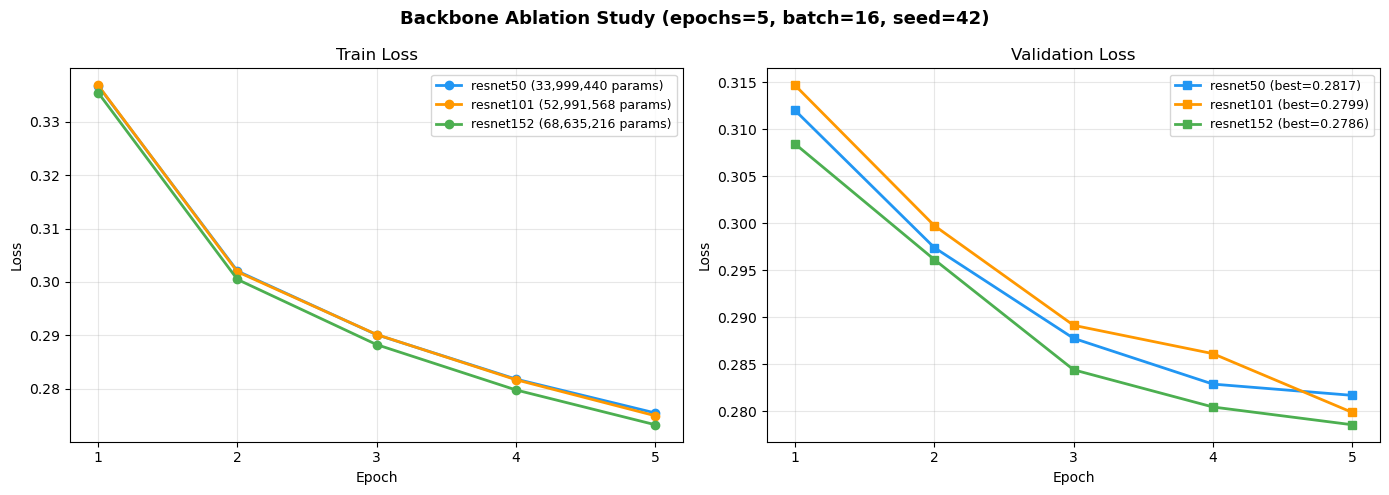

그래프 저장: /home/jovyan/work/노드실습/GoingDeeper/4.Poseestimation/mpii/models/ablation_backbone_loss.png


In [9]:
# ============================================================
# Loss 곡선 시각화
# ============================================================
colors = {'resnet50': '#2196F3', 'resnet101': '#FF9800', 'resnet152': '#4CAF50'}
epochs_range = range(1, EPOCHS + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(
    f'Backbone Ablation Study (epochs={EPOCHS}, batch={BATCH_SIZE}, seed={SEED})',
    fontsize=13, fontweight='bold'
)

for name, r in results.items():
    c = colors[name]
    # Train Loss
    axes[0].plot(epochs_range, r['train'], marker='o', color=c,
                 label=f'{name} ({r["params"]:,} params)', linewidth=2)
    # Val Loss
    axes[1].plot(epochs_range, r['val'], marker='s', color=c,
                 label=f'{name} (best={r["best_val"]:.4f})', linewidth=2)

for ax, title in zip(axes, ['Train Loss', 'Validation Loss']):
    ax.set_title(title, fontsize=12)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))  # x축 정수

plt.tight_layout()
save_path = os.path.join(MODEL_PATH, 'ablation_backbone_loss.png')
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'그래프 저장: {save_path}')

In [10]:
# ============================================================
# Epoch별 상세 결과 출력
# ============================================================
print(f'\n{'Epoch':<6}', end='')
for name in BACKBONES:
    print(f'  {name+" Train":>14} {name+" Val":>14}', end='')
print()
print('-' * (6 + len(BACKBONES) * 30))

for i in range(EPOCHS):
    print(f'{i+1:<6}', end='')
    for name in BACKBONES:
        r = results[name]
        print(f'  {r["train"][i]:>14.4f} {r["val"][i]:>14.4f}', end='')
    print()

# ============================================================
# 분석 요약
# ============================================================
print('\n[분석 요약]')
base = results['resnet50']
for name in ['resnet101', 'resnet152']:
    r = results[name]
    param_diff  = (r['params'] - base['params']) / base['params'] * 100
    val_diff    = r['best_val'] - base['best_val']
    print(f'- {name} vs resnet50: '
          f'파라미터 +{param_diff:.1f}%, '
          f'best_val_loss {val_diff:+.4f} '
          f'({"개선" if val_diff < 0 else "악화"})')


Epoch   resnet50 Train   resnet50 Val  resnet101 Train  resnet101 Val  resnet152 Train  resnet152 Val
------------------------------------------------------------------------------------------------
1               0.3367         0.3120          0.3368         0.3147          0.3354         0.3084
2               0.3020         0.2974          0.3019         0.2997          0.3005         0.2961
3               0.2901         0.2878          0.2902         0.2891          0.2883         0.2844
4               0.2818         0.2829          0.2817         0.2861          0.2798         0.2805
5               0.2755         0.2817          0.2750         0.2799          0.2733         0.2786

[분석 요약]
- resnet101 vs resnet50: 파라미터 +55.9%, best_val_loss -0.0018 (개선)
- resnet152 vs resnet50: 파라미터 +101.9%, best_val_loss -0.0031 (개선)


---
## 7. 추론 및 skeleton 시각화

In [11]:
# ============================================================
# MPII Keypoint & Skeleton 정의
# ============================================================
R_ANKLE=0; R_KNEE=1; R_HIP=2; L_HIP=3; L_KNEE=4; L_ANKLE=5
PELVIS=6; THORAX=7; UPPER_NECK=8; HEAD_TOP=9
R_WRIST=10; R_ELBOW=11; R_SHOULDER=12
L_SHOULDER=13; L_ELBOW=14; L_WRIST=15

MPII_BONES = [
    [R_ANKLE,R_KNEE],[R_KNEE,R_HIP],[R_HIP,PELVIS],
    [L_HIP,PELVIS],[L_HIP,L_KNEE],[L_KNEE,L_ANKLE],
    [PELVIS,THORAX],[THORAX,UPPER_NECK],[UPPER_NECK,HEAD_TOP],
    [R_WRIST,R_ELBOW],[R_ELBOW,R_SHOULDER],[THORAX,R_SHOULDER],
    [THORAX,L_SHOULDER],[L_SHOULDER,L_ELBOW],[L_ELBOW,L_WRIST]
]


def find_keypoints(heatmaps):
    """
    heatmap에서 keypoint 좌표 추출 (subpixel 보정 포함)

    처리 과정:
    1. argmax로 각 채널의 최대값 위치 탐색
    2. 주변 3×3 patch의 최대값 방향으로 0.25픽셀 보정
    3. heatmap 크기로 나눠 0~1 정규화

    Args:
        heatmaps: (H, W, C) 형태의 heatmap 텐서
    Returns:
        (C, 2) 형태의 정규화된 keypoint 좌표
    """
    H, W, C = heatmaps.shape

    # flatten 후 argmax → (y, x) 좌표 계산
    flat = heatmaps.reshape(-1, C)
    idx  = torch.argmax(flat, dim=0)
    y_raw = idx // W
    x_raw = idx - W * y_raw

    # 경계 처리를 위해 1픽셀 패딩
    padded = F.pad(heatmaps.permute(2,0,1), (1,1,1,1)).permute(1,2,0)

    adjusted = []
    for i in range(C):
        mx, my = int(x_raw[i]) + 1, int(y_raw[i]) + 1
        patch  = padded[my-1:my+2, mx-1:mx+2, i].clone()
        patch[1, 1] = 0  # 중심값 제거 후 주변 최대값 방향으로 보정
        ni   = torch.argmax(patch.reshape(-1)).item()
        ny, nx = ni//3, ni%3
        # 최대값 방향으로 0.25픽셀 이동 (subpixel refinement)
        adj_x = x_raw[i].item() + (nx-1)/4.0
        adj_y = y_raw[i].item() + (ny-1)/4.0
        adjusted.append((adj_x, adj_y))

    kps = torch.clamp(torch.tensor(adjusted), 0, H)
    return kps / H  # 0~1 정규화


def predict(model, image_path, device):
    """단일 이미지에 대한 keypoint 예측"""
    image = Image.open(image_path).convert('RGB')
    preprocess = transforms.Compose([
        transforms.Resize((256, 256)),
        transforms.ToTensor(),
        transforms.Lambda(lambda x: x * 2 - 1)  # [0,1] → [-1,1]
    ])
    x = preprocess(image).unsqueeze(0).to(device)
    model.eval()
    with torch.no_grad():
        out = model(x)
    if not isinstance(out, list):
        out = [out]
    # 마지막 스택 heatmap 사용, (H,W,C) 형태로 변환
    heatmap = out[-1].squeeze(0).permute(1,2,0).cpu()
    return image, find_keypoints(heatmap)


def draw_skeleton(image, keypoints, ax, title=''):
    """이미지 위에 keypoint(점) + skeleton(선) 시각화"""
    img_np = np.array(image)
    H, W   = img_np.shape[:2]
    ax.imshow(img_np)

    # keypoint 픽셀 좌표 계산 (정규화 → 실제 픽셀)
    joints = [(kp[0].item()*W, kp[1].item()*H) for kp in keypoints]

    # skeleton 선 그리기
    for b in MPII_BONES:
        j1, j2 = joints[b[0]], joints[b[1]]
        ax.plot([j1[0],j2[0]], [j1[1],j2[1]], linewidth=3, alpha=0.8)

    # keypoint 점 그리기
    for jx, jy in joints:
        ax.scatter(jx, jy, s=25, c='red', zorder=5)

    ax.set_title(title, fontsize=10)
    ax.axis('off')

print('완료')

완료


/tmp/ipykernel_860/520959771.py:37: UserWarning: Glyph 48324 (\N{HANGUL SYLLABLE BYEOL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_860/520959771.py:37: UserWarning: Glyph 44208 (\N{HANGUL SYLLABLE GYEOL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_860/520959771.py:37: UserWarning: Glyph 44284 (\N{HANGUL SYLLABLE GWA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_860/520959771.py:37: UserWarning: Glyph 48708 (\N{HANGUL SYLLABLE BI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_860/520959771.py:37: UserWarning: Glyph 44368 (\N{HANGUL SYLLABLE GYO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_860/520959771.py:39: UserWarning: Glyph 48324 (\N{HANGUL SYLLABLE BYEOL}) missing from font(s) DejaVu Sans.
  plt.savefig(save_path, dpi=150, bbox_inches='tight')
/tmp/ipykernel_860/520959771.py:39: UserWarning: Glyph 44208 (\N{HANGUL SYLLABLE GYEOL}) missing from font(s)

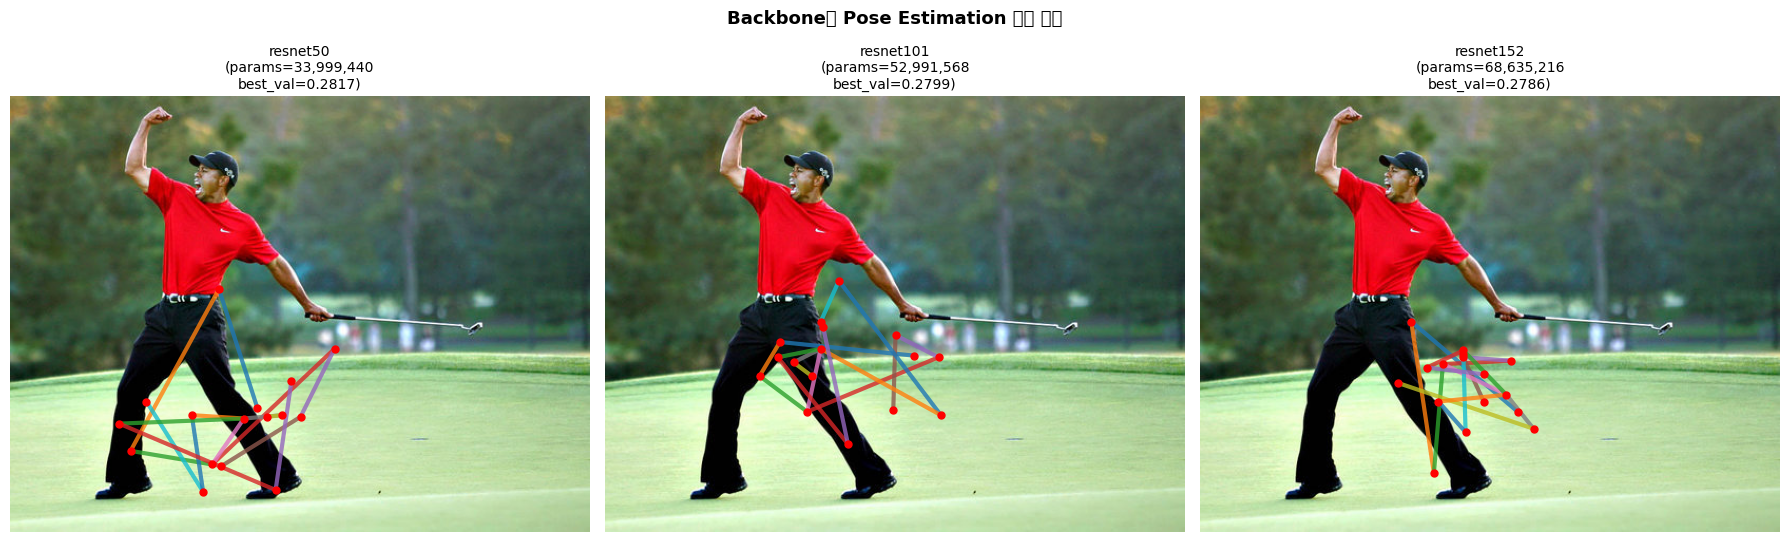

시각화 저장: /home/jovyan/work/노드실습/GoingDeeper/4.Poseestimation/mpii/models/ablation_backbone_skeleton.png


In [12]:
# ============================================================
# 테스트 이미지로 backbone별 추론 결과 비교
# best model 가중치 로드 후 동일 이미지에서 skeleton 시각화
# ============================================================
test_image_path = os.path.join(PROJECT_PATH, 'test_image.jpg')

# 테스트 이미지 없으면 다운로드
if not os.path.exists(test_image_path):
    os.system('wget "https://images.unsplash.com/photo-1546427660-eb346c344ba5'
              '?q=80&w=2787&auto=format&fit=crop" '
              f'-O {test_image_path} -q')

fig, axes = plt.subplots(1, len(BACKBONES), figsize=(6*len(BACKBONES), 6))
fig.suptitle('Backbone별 Pose Estimation 결과 비교', fontsize=13, fontweight='bold')

for ax, backbone in zip(axes, BACKBONES):
    # best model 가중치 로드
    model = SimpleBaseline(backbone=backbone, num_heatmap=NUM_HEATMAP, pretrained=False)
    model.to(device)

    best_path = results[backbone].get('best_model')  # Trainer에서 저장한 경로
    if best_path and os.path.exists(best_path):
        state = torch.load(best_path, map_location=device)
        # DataParallel 사용 시 'module.' prefix 제거
        if any(k.startswith('module.') for k in state):
            state = {k.replace('module.', ''): v for k, v in state.items()}
        model.load_state_dict(state)

    image, keypoints = predict(model, test_image_path, device)
    draw_skeleton(
        image, keypoints, ax,
        title=f'{backbone}\n(params={results[backbone]["params"]:,}\nbest_val={results[backbone]["best_val"]:.4f})'
    )
    del model
    torch.cuda.empty_cache()

plt.tight_layout()
save_path = os.path.join(MODEL_PATH, 'ablation_backbone_skeleton.png')
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'시각화 저장: {save_path}')

---
## 8. 실험 결과 정리

In [13]:
# ============================================================
# 최종 결과 요약 출력 (팀 공유용)
# ============================================================
print('=' * 65)
print('  [Ablation Study] SimpleBaseline Backbone 교체 실험 결과')
print(f'  공통 조건: epochs={EPOCHS}, batch_size={BATCH_SIZE}, seed={SEED}, lr={LR}')
print('=' * 65)
print(f'{"Backbone":<12} {"Params":>12} {"Best Val Loss":>15}')
print('-' * 65)

best_name = min(results, key=lambda k: results[k]['best_val'])
for name, r in results.items():
    marker = ' ← Best' if name == best_name else ''
    print(f'{name:<12} {r["params"]:>12,} {r["best_val"]:>15.4f}{marker}')

print('=' * 65)
print(f'\n결론: best backbone = {best_name} (val_loss={results[best_name]["best_val"]:.4f})')

# resnet50 기준 상대 비교
base_val = results['resnet50']['best_val']
print('\n[resnet50 기준 비교]')
for name in ['resnet101', 'resnet152']:
    diff = results[name]['best_val'] - base_val
    print(f'- {name}: {diff:+.4f} ({"개선" if diff < 0 else "악화"})')

  [Ablation Study] SimpleBaseline Backbone 교체 실험 결과
  공통 조건: epochs=5, batch_size=16, seed=42, lr=0.0007
Backbone           Params   Best Val Loss
-----------------------------------------------------------------
resnet50       33,999,440          0.2817
resnet101      52,991,568          0.2799
resnet152      68,635,216          0.2786 ← Best

결론: best backbone = resnet152 (val_loss=0.2786)

[resnet50 기준 비교]
- resnet101: -0.0018 (개선)
- resnet152: -0.0031 (개선)
